# Lecture 3 Exercise 1 - Solution

## Objective

The goal of this assignment is to analyze text data by creating **word embeddings** using **Word2Vec**, **GloVe**, or **both**. You will visualize and interpret **semantic relationships** between words.

## Step 1: Import Libraries

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mastodon import Mastodon
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import umap
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("Libraries imported successfully!")

/Users/matthiasbogaert/anaconda3/envs/SMWA2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matthiasbogaert/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matthiasbogaert/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/matthiasbogaert/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Step 2: Collect Data from Mastodon

In [ ]:
import sys

# Import Mastodon utility functions
sys.path.append('../../../Lecture1/Code/Examples')
from mastodon_utils import fetch_hashtag_toots, add_clean_content, filter_by_language, select_columns
from config import MASTODON_ACCESS_TOKEN, MASTODON_API_BASE_URL

# Initialize Mastodon client
mastodon = Mastodon(
    access_token=MASTODON_ACCESS_TOKEN,
    api_base_url=MASTODON_API_BASE_URL
)

# Choose your hashtag
hashtag = "ArtificialIntelligence"
max_toots = 1000

# Collect posts with automatic pagination
print(f"Collecting posts about #{hashtag}...")
df_toots = fetch_hashtag_toots(mastodon, hashtag, max_toots=max_toots, verbose=True)

print(f"\n✓ Collected {len(df_toots)} posts")

# Clean HTML tags from content
df_toots = add_clean_content(df_toots)

# Filter for English language
df_toots = filter_by_language(df_toots, language='en', verbose=True)

# Select relevant columns (text only for this exercise)
df_toots = select_columns(df_toots, columns=['text'])

print(f"\n✓ Dataset after filtering: {len(df_toots)} posts")

Fetching toots for #ArtificialIntelligence...

Batch 1: 40 toots
Batch 2: 40 toots (total: 80)
Batch 3: 40 toots (total: 120)
Batch 4: 40 toots (total: 160)
Batch 5: 40 toots (total: 200)
Batch 6: 40 toots (total: 240)
Batch 7: 40 toots (total: 280)
Batch 8: 40 toots (total: 320)
Batch 9: 40 toots (total: 360)
Batch 10: 40 toots (total: 400)
Batch 11: 40 toots (total: 440)
Batch 12: 40 toots (total: 480)
Batch 13: 40 toots (total: 520)
Batch 14: 40 toots (total: 560)
Batch 15: 40 toots (total: 600)
Batch 16: 40 toots (total: 640)
Batch 17: 40 toots (total: 680)
Batch 18: 40 toots (total: 720)
Batch 19: 40 toots (total: 760)
Batch 20: 40 toots (total: 800)
Batch 21: 40 toots (total: 840)
Batch 22: 40 toots (total: 880)
Batch 23: 40 toots (total: 920)
Batch 24: 40 toots (total: 960)
Batch 25: 40 toots (total: 1000)

✓ Total retrieved: 1000 toots

✓ Collected 1000 posts
Language filter ('en'):
  Before: 1000 toots
  After: 866 toots (86.6%)

✓ Dataset after filtering: 866 posts

First pos

In [ ]:
from langdetect import detect, LangDetectException

def detect_language(text):
    """
    Detect language of text using langdetect.
    Returns 'en' for English, other codes for other languages, or None if detection fails.
    """
    try:
        return detect(text)
    except LangDetectException:
        return None

# Apply language detection to all texts
print("Detecting language for each post...")
df_toots['detected_lang'] = df_toots['text'].apply(detect_language)

# Check language distribution
print("\nDetected language distribution:")
print(df_toots['detected_lang'].value_counts())

# Filter for English only
initial_count = len(df_toots)
df_toots = df_toots[df_toots['detected_lang'] == 'en'].copy()
df_toots = df_toots.drop('detected_lang', axis=1).reset_index(drop=True)

print(f"\nAfter additional language filtering:")
print(f"  Before: {initial_count} posts")
print(f"  After: {len(df_toots)} posts ({len(df_toots)/initial_count*100:.1f}%)")

# Extract texts for processing
texts = df_toots['text'].tolist()

print(f"\nFinal dataset: {len(texts)} posts")

Detecting language for each post...

Detected language distribution:
detected_lang
en    769
vi     78
it     11
fr      5
ko      1
af      1
es      1
Name: count, dtype: int64

After additional language filtering:
  Before: 866 posts
  After: 769 posts (88.8%)

Final dataset: 769 posts

First post example:
The “But this stuff is not going away” argument for letting giant US tech companies inject AI into every facet life in a UK town is very weak. Not dissimilar to “we mustn’t get left behind”.https://ww...


### Additional Language Filtering

The Mastodon API's language field isn't always accurate. Let's use `langdetect` for more robust language detection to ensure we only analyze English text.

## Step 3: Preprocess the Text Data

In [5]:
def preprocess_text(text, remove_stopwords=True):
    """
    Preprocess text for word embeddings:
    - Convert to lowercase
    - Remove URLs, mentions, hashtags
    - Remove punctuation and numbers
    - Tokenize
    - Remove stopwords (optional)
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    return tokens

# Preprocess all texts
print("Preprocessing texts...")
tokens = [preprocess_text(text) for text in texts]

# Remove empty documents
tokens = [doc for doc in tokens if len(doc) > 0]

print(f"Preprocessed {len(tokens)} documents")
print(f"Example tokenized document: {tokens[0][:20]}")

Preprocessing texts...
Preprocessed 761 documents
Example tokenized document: ['stuff', 'going', 'away', 'argument', 'letting', 'giant', 'tech', 'companies', 'inject', 'every', 'facet', 'life', 'town', 'weak', 'dissimilar', 'get', 'left', 'behind']


## Step 4: Train Word2Vec Model

In [6]:
print("Training Word2Vec model...")

# Train Word2Vec model with Skip-gram
model = Word2Vec(
    sentences=tokens,
    vector_size=100,      # Dimensionality of word vectors
    window=5,             # Maximum distance between current and predicted word
    min_count=3,          # Ignores words with frequency lower than this
    sg=1,                 # 1 for skip-gram, 0 for CBOW
    workers=4,            # Number of worker threads
    epochs=50,            # Number of iterations
    seed=42
)

print(f"Model trained successfully!")
print(f"Vocabulary size: {len(model.wv)}")
print(f"Vector size: {model.wv.vector_size}")

Training Word2Vec model...
Model trained successfully!
Vocabulary size: 1740
Vector size: 100


## Step 5: Explore Word Similarities

In [9]:
# Find similar words to key terms
key_words = ['ai', 'intelligence', 'learning', 'technology', 'data']

print("Word Similarities:")
print("=" * 60)

for word in key_words:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=5)
        print(f"\nWords similar to '{word}':")
        for similar_word, score in similar:
            print(f"  {similar_word:20s} {score:.4f}")
    else:
        print(f"\n'{word}' not in vocabulary")

Word Similarities:

'ai' not in vocabulary

Words similar to 'intelligence':
  artificial           0.8492
  discusses            0.5719
  spacebased           0.5664
  predict              0.5571
  redefining           0.5565

Words similar to 'learning':
  humanitarian         0.7231
  peer                 0.6917
  gamification         0.6823
  organizations        0.6645
  disaster             0.6438

Words similar to 'technology':
  humanity             0.5633
  law                  0.5417
  specops              0.5260
  stable               0.5176
  implementation       0.5164

Words similar to 'data':
  purpose              0.6300
  centres              0.6180
  malicious            0.6080
  centers              0.5977
  passwords            0.5846


### Explore Analogies

Word embeddings capture semantic relationships. Try some analogies!

In [11]:
# Example analogies
print("\nWord Analogies:")
print("=" * 60)

# Try some analogies (results will vary based on your data)
try:
    # Example: machine is to learning as deep is to ...
    result = model.wv.most_similar(positive=['deep', 'learning'], negative=['machine'], topn=3)
    print("\nmachine is to learning as deep is to ...")
    for word, score in result:
        print(f"  {word:20s} {score:.4f}")
except:
    print("\nNot enough vocabulary for this analogy")

try:
    # Another example
    result = model.wv.most_similar(positive=['neural', 'network'], negative=['artificial'], topn=3)
    print("\nartificial is to neural as network is to ...")
    for word, score in result:
        print(f"  {word:20s} {score:.4f}")
except:
    print("\nNot enough vocabulary for this analogy")


Word Analogies:

machine is to learning as deep is to ...
  piker                0.5517
  success              0.5455
  disaster             0.5444

artificial is to neural as network is to ...
  planetary            0.6340
  networks             0.6037
  trained              0.5516


## Step 6: Visualize Embeddings with t-SNE

In [12]:
print("Preparing data for visualization...")

# Select top N most frequent words for visualization
num_words = 500
words = list(model.wv.index_to_key)[:num_words]

# Extract word vectors
word_vectors = np.array([model.wv[word] for word in words])

print(f"Visualizing {len(words)} words...")
print("Running t-SNE (this may take a moment)...")

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
    verbose=1
)

embeddings_2d = tsne.fit_transform(word_vectors)

print("t-SNE completed!")

Preparing data for visualization...
Visualizing 500 words...
Running t-SNE (this may take a moment)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 500 samples in 0.000s...
[t-SNE] Computed neighbors for 500 samples in 0.081s...
[t-SNE] Computed conditional probabilities for sample 500 / 500
[t-SNE] Mean sigma: 1.256964
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.857449
[t-SNE] KL divergence after 1000 iterations: 1.753909
t-SNE completed!


### Create t-SNE Visualization

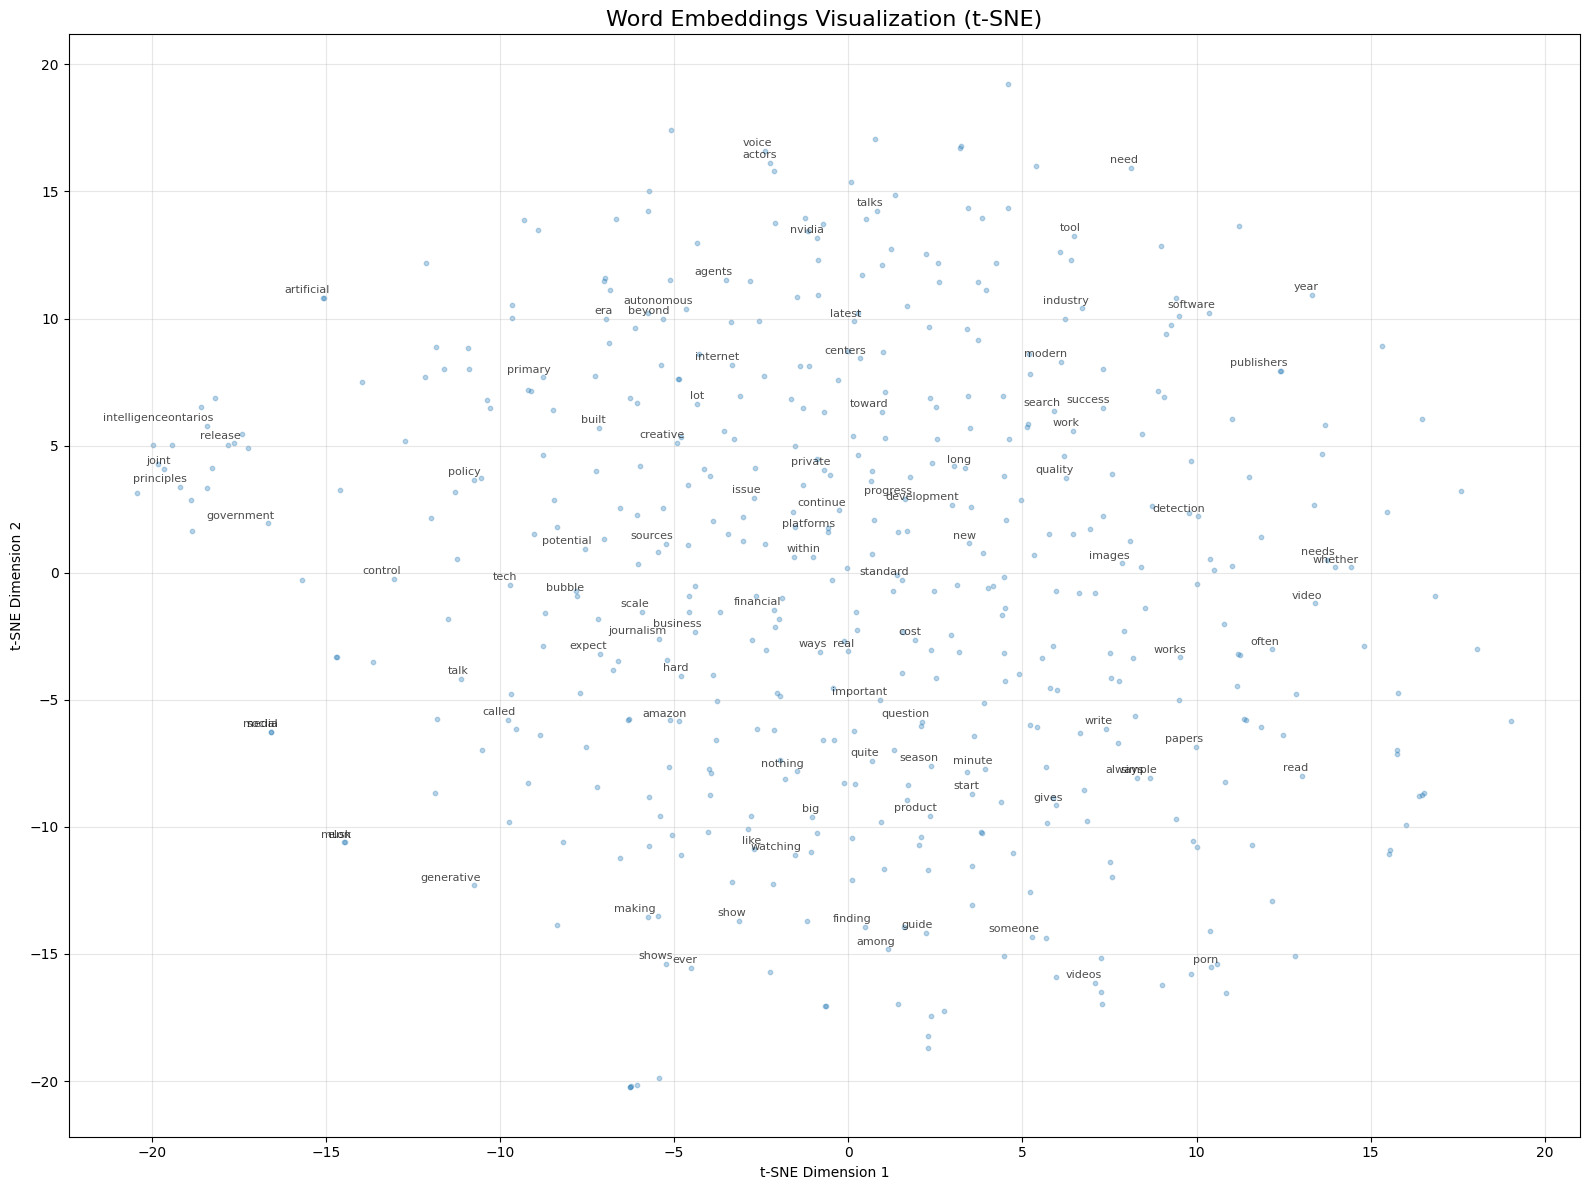


Words that are closer together in this plot have similar meanings or contexts.


In [13]:
# Create the plot
plt.figure(figsize=(16, 12))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.3, s=10)

# Add labels for a subset of words (to avoid overcrowding)
# Label every 5th word
for i in range(0, len(words), 5):
    plt.annotate(
        words[i],
        xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
        xytext=(5, 2),
        textcoords='offset points',
        ha='right',
        va='bottom',
        fontsize=8,
        alpha=0.7
    )

plt.title('Word Embeddings Visualization (t-SNE)', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWords that are closer together in this plot have similar meanings or contexts.")

## Step 7: Visualize with UMAP (Alternative)

In [14]:
print("Running UMAP (this may take a moment)...")

# Apply UMAP
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric='euclidean',
    random_state=42
)

embeddings_2d_umap = umap_model.fit_transform(word_vectors)

print("UMAP completed!")

Running UMAP (this may take a moment)...


/Users/matthiasbogaert/anaconda3/envs/SMWA2026/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completed!


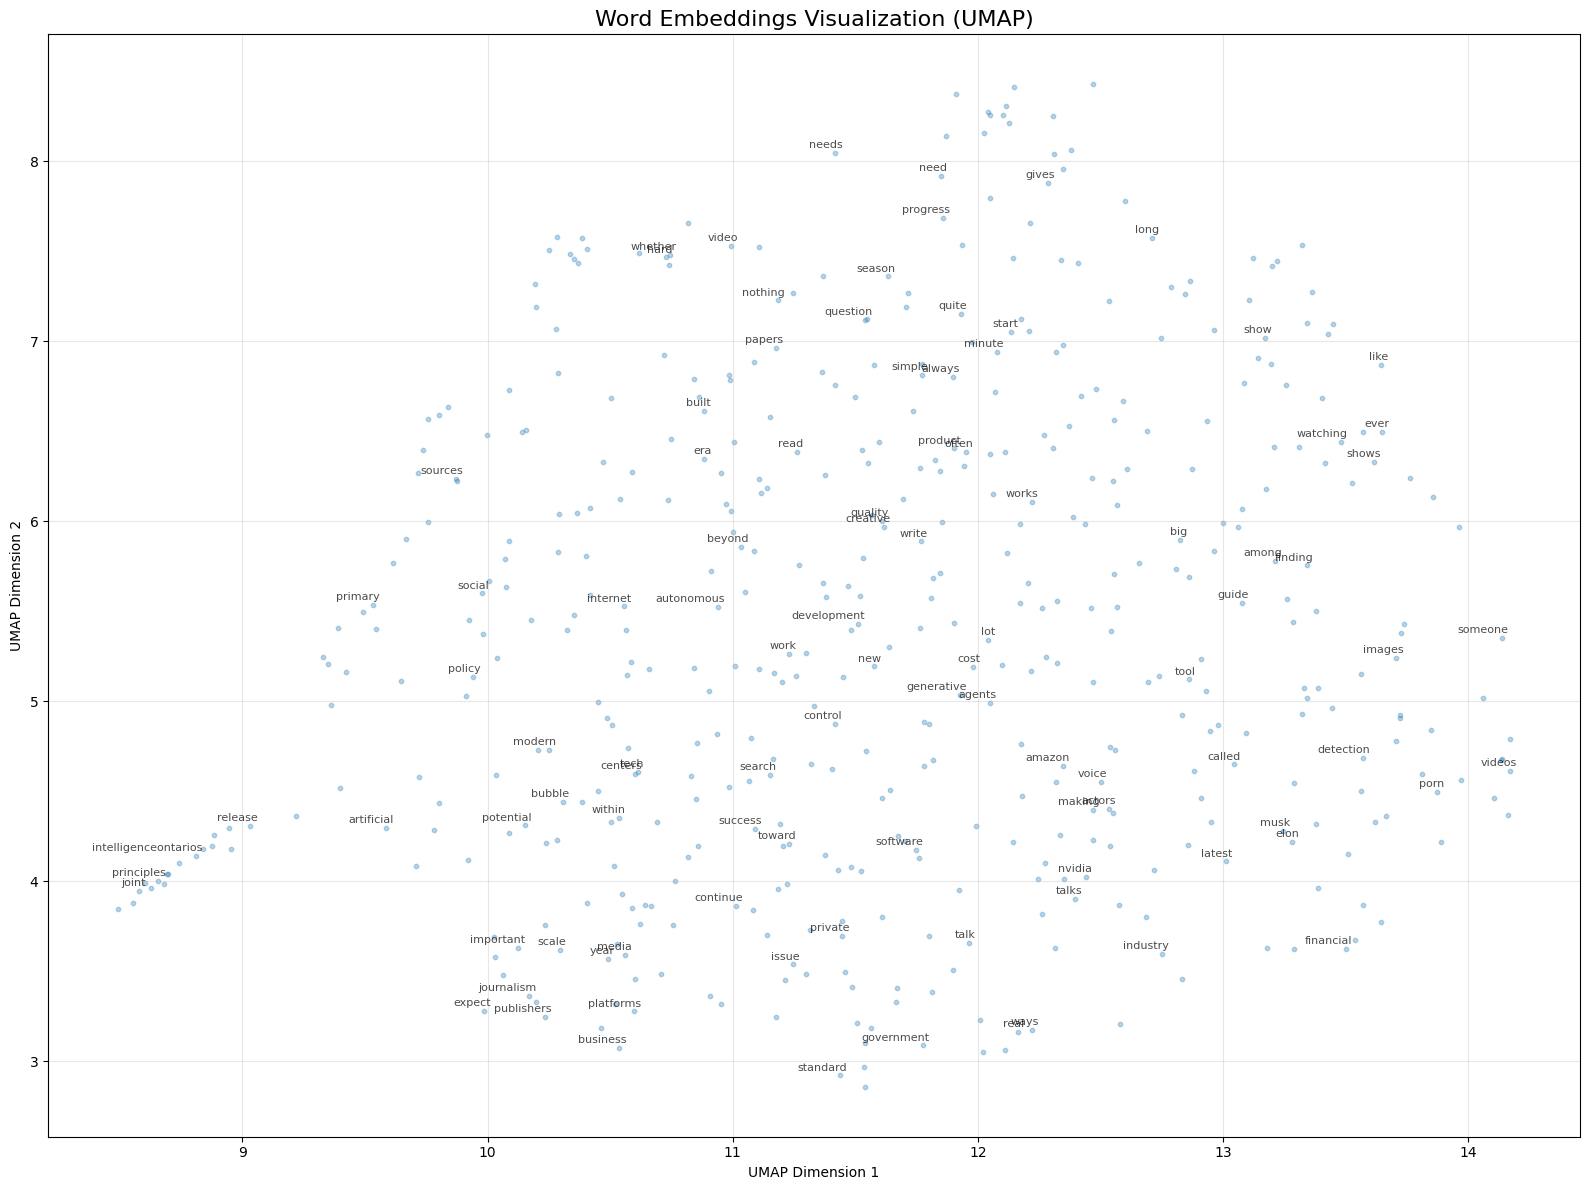


UMAP often preserves global structure better than t-SNE.


In [15]:
# Create UMAP plot
plt.figure(figsize=(16, 12))
plt.scatter(embeddings_2d_umap[:, 0], embeddings_2d_umap[:, 1], alpha=0.3, s=10)

# Add labels for a subset of words
for i in range(0, len(words), 5):
    plt.annotate(
        words[i],
        xy=(embeddings_2d_umap[i, 0], embeddings_2d_umap[i, 1]),
        xytext=(5, 2),
        textcoords='offset points',
        ha='right',
        va='bottom',
        fontsize=8,
        alpha=0.7
    )

plt.title('Word Embeddings Visualization (UMAP)', fontsize=16)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nUMAP often preserves global structure better than t-SNE.")

## Step 8: Experiment with Different Parameters

Let's compare models with different parameter settings.

In [17]:
# Compare different vector sizes
print("Comparing different parameter settings...")
print("=" * 60)

# Model 1: Small vectors (50 dimensions)
model_small = Word2Vec(sentences=tokens, vector_size=50, window=5, min_count=3, sg=1, epochs=50, seed=42)

# Model 2: Large vectors (200 dimensions)
model_large = Word2Vec(sentences=tokens, vector_size=200, window=5, min_count=3, sg=1, epochs=50, seed=42)

# Model 3: Different window size
model_window = Word2Vec(sentences=tokens, vector_size=100, window=10, min_count=3, sg=1, epochs=50, seed=42)

# Model 4: CBOW instead of Skip-gram
model_cbow = Word2Vec(sentences=tokens, vector_size=100, window=5, min_count=3, sg=0, epochs=50, seed=42)

# Compare results for a test word
test_word = 'technology'

if test_word in model.wv:
    print(f"\nSimilar words to '{test_word}' with different models:\n")
    
    print("Original model (vector_size=100, window=5, skip-gram):")
    for word, score in model.wv.most_similar(test_word, topn=5):
        print(f"  {word:20s} {score:.4f}")
    
    print("\nSmall vectors (vector_size=50):")
    for word, score in model_small.wv.most_similar(test_word, topn=5):
        print(f"  {word:20s} {score:.4f}")
    
    print("\nLarge vectors (vector_size=200):")
    for word, score in model_large.wv.most_similar(test_word, topn=5):
        print(f"  {word:20s} {score:.4f}")
    
    print("\nLarger window (window=10):")
    for word, score in model_window.wv.most_similar(test_word, topn=5):
        print(f"  {word:20s} {score:.4f}")
    
    print("\nCBOW algorithm (sg=0):")
    for word, score in model_cbow.wv.most_similar(test_word, topn=5):
        print(f"  {word:20s} {score:.4f}")
else:
    print(f"'{test_word}' not in vocabulary")

Comparing different parameter settings...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Similar words to 'technology' with different models:

Original model (vector_size=100, window=5, skip-gram):
  humanity             0.5633
  law                  0.5417
  specops              0.5260
  stable               0.5176
  implementation       0.5164

Small vectors (vector_size=50):
  humanity             0.6069
  stable               0.5740
  reshaping            0.5671
  contracts            0.5647
  book                 0.5611

Large vectors (vector_size=200):
  humanity             0.5837
  law                  0.5370
  specops              0.5334
  implementation       0.5267
  fully                0.5262

Larger window (window=10):
  humanity             0.4915
  reshaping            0.4595
  frameworks           0.4561
  fully                0.4474
  specops              0.4474

CBOW algorithm (sg=0):
  new                  0.8815
  reshaping            0.8784
  ways                 0.8780
  legacy               0.8732
  traditional          0.8591


## Key Findings and Insights

### Parameter Effects:

1. **Vector Size (vector_size)**:
   - Smaller vectors (50-100): Faster to train, less memory, but may miss nuances
   - Larger vectors (200-300): Capture more semantic relationships, slower to train

2. **Window Size (window)**:
   - Smaller window (2-5): Captures more syntactic relationships (words that appear together)
   - Larger window (5-10): Captures more semantic/topical relationships

3. **Algorithm (sg: Skip-gram vs CBOW)**:
   - Skip-gram (sg=1): Better for small datasets, better with rare words
   - CBOW (sg=0): Faster to train, better for frequent words

4. **Min Count (min_count)**:
   - Higher values remove rare words, reducing vocabulary size
   - Lower values keep more words but may include noise

### Observations:
- Words that are semantically similar cluster together in the embedding space
- The visualization helps identify topics and themes in the data
- Different parameter settings can reveal different aspects of word relationships